In [1]:
import pandas as pd

# 데이터 로드
residual1 = pd.read_csv('data/z24_residual_features_frac_0.1.csv')
residual2 = pd.read_csv('data/z24_residual_features_frac_0.2.csv')
residual3 = pd.read_csv('data/z24_residual_features_frac_0.3.csv')

# datasets 딕셔너리 생성
datasets = {
    0.1: residual1.copy(),
    0.2: residual2.copy(),
    0.3: residual3.copy()
}

# 정보 확인
print("residual1 info")
residual1.info()
print("\n" + "="*50 + "\n")

print("residual2 info")
residual2.info()
print("\n" + "="*50 + "\n")

print("residual3 info")
residual3.info()


residual1 info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sample_idx  400 non-null    int64  
 1   f1          366 non-null    float64
 2   f2          359 non-null    float64
 3   f3          359 non-null    float64
 4   f4          356 non-null    float64
 5   status      400 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 18.9+ KB


residual2 info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sample_idx  400 non-null    int64  
 1   f1          323 non-null    float64
 2   f2          320 non-null    float64
 3   f3          321 non-null    float64
 4   f4          316 non-null    float64
 5   status      400 non-null    object 
dtypes: float64(4), int64(1), object(1)
m

In [2]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ['f1', 'f2', 'f3', 'f4']
palette = {
    "train": "#2ca02c",
    "Normal": "#1f77b4",
    "Damaged": "#d62728"
}

def plot_feature_pairs(df, title):
    pairs = list(itertools.combinations(feature_cols, 2))
    n_pairs = len(pairs)

    ncols = 3
    nrows = int(np.ceil(n_pairs / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    for i, (xcol, ycol) in enumerate(pairs):
        ax = axes[i]
        sns.scatterplot(
            data=df,
            x=xcol,
            y=ycol,
            hue='status',
            palette=palette,
            alpha=0.6,
            s=18,
            edgecolor=None,
            ax=ax,
            legend=(i == 0)
        )
        ax.set_title(f'{xcol} vs {ycol}')

        if i != 0:
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

    # 남는 subplot 제거
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


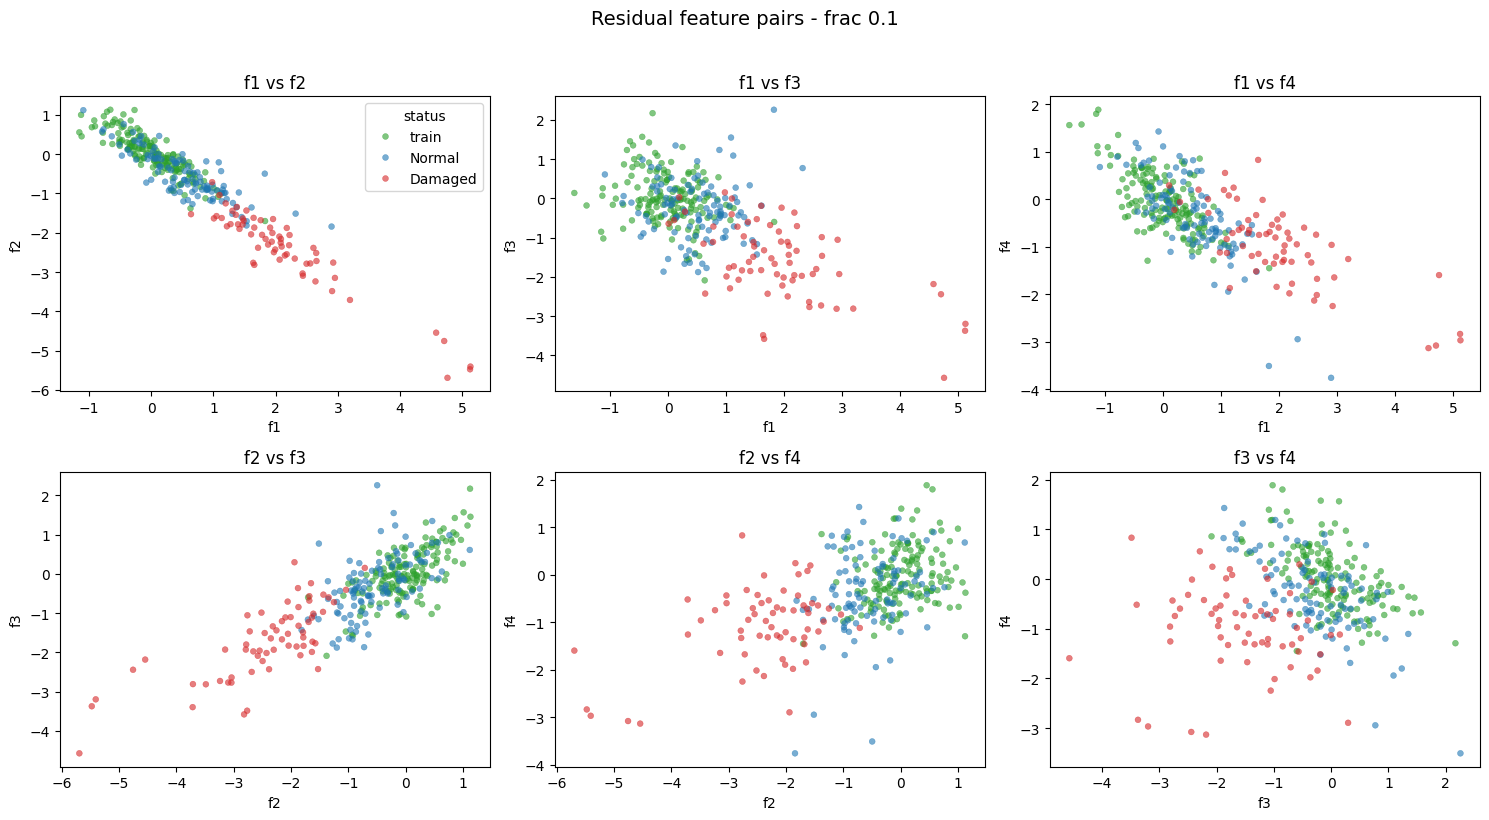

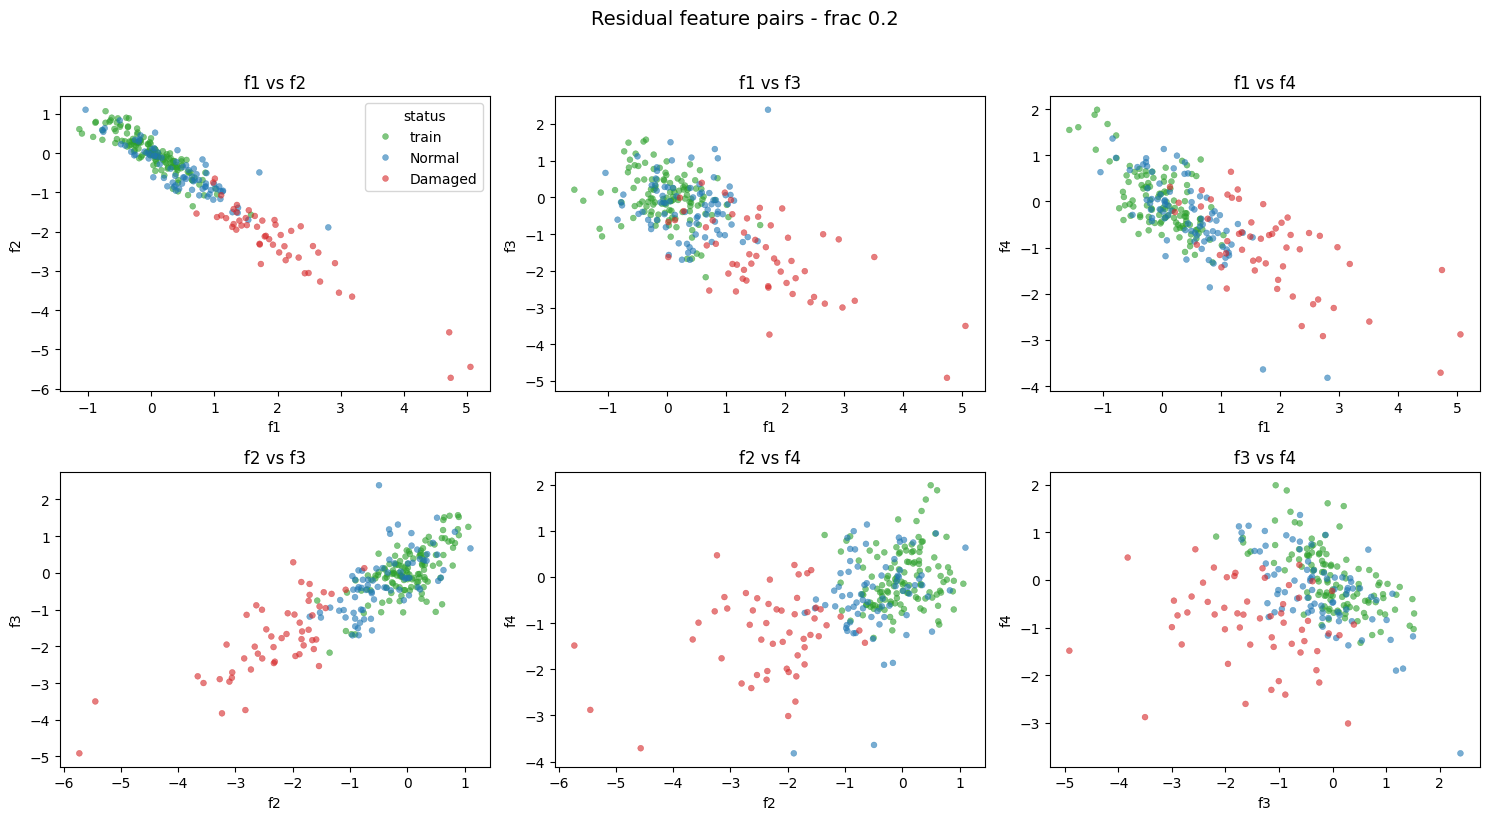

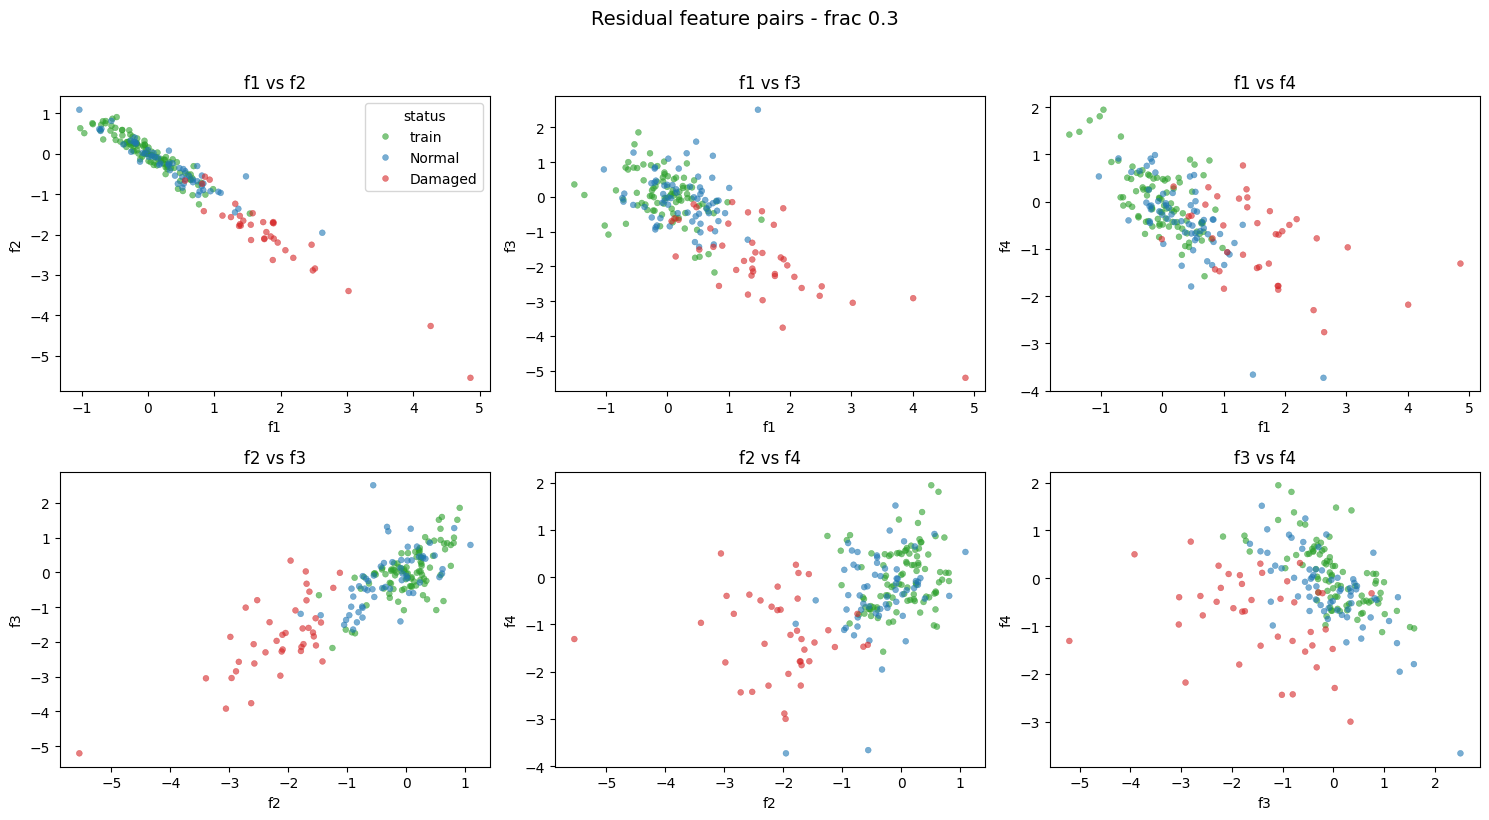

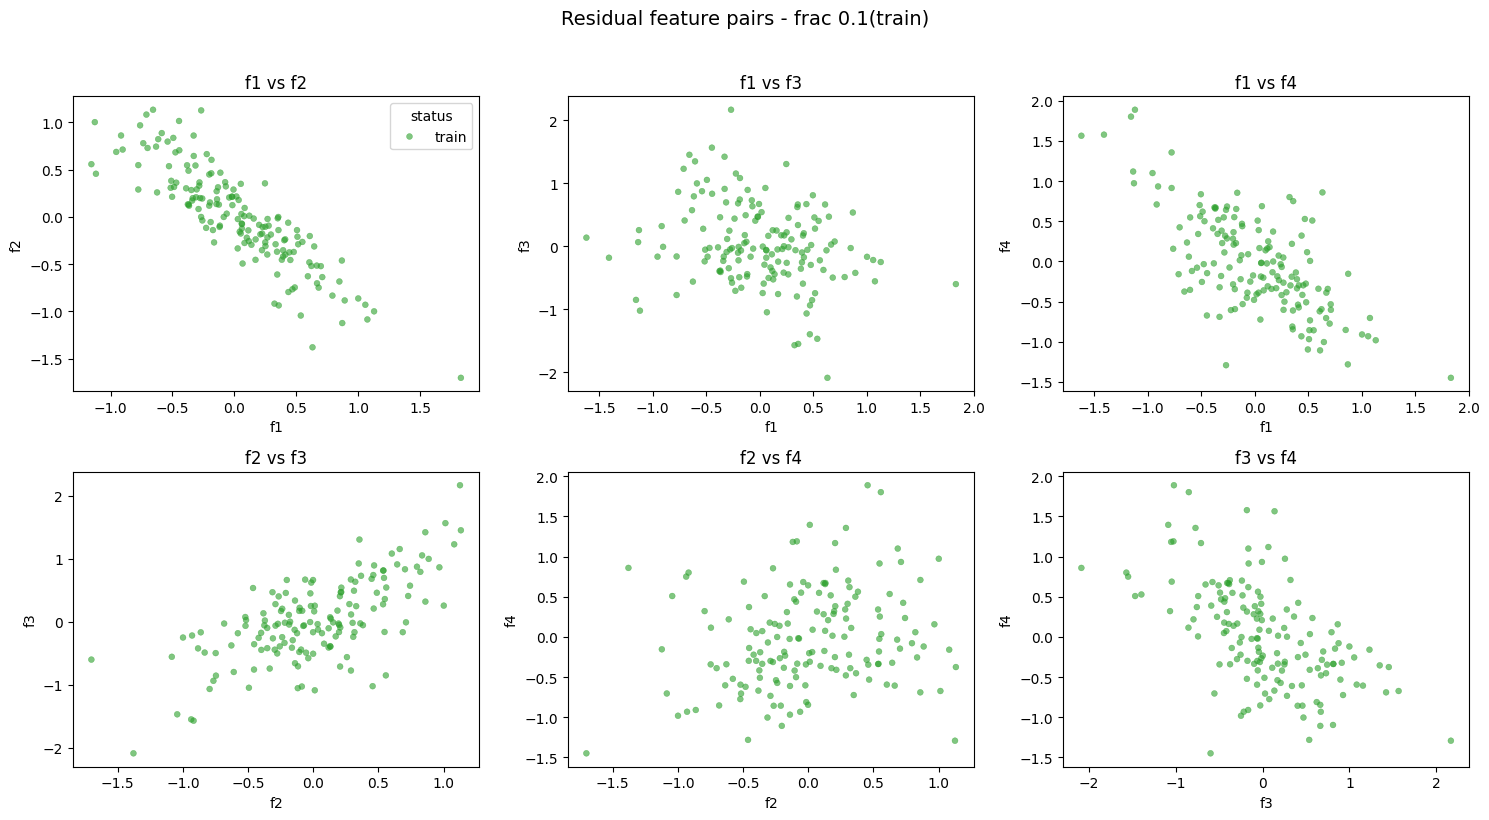

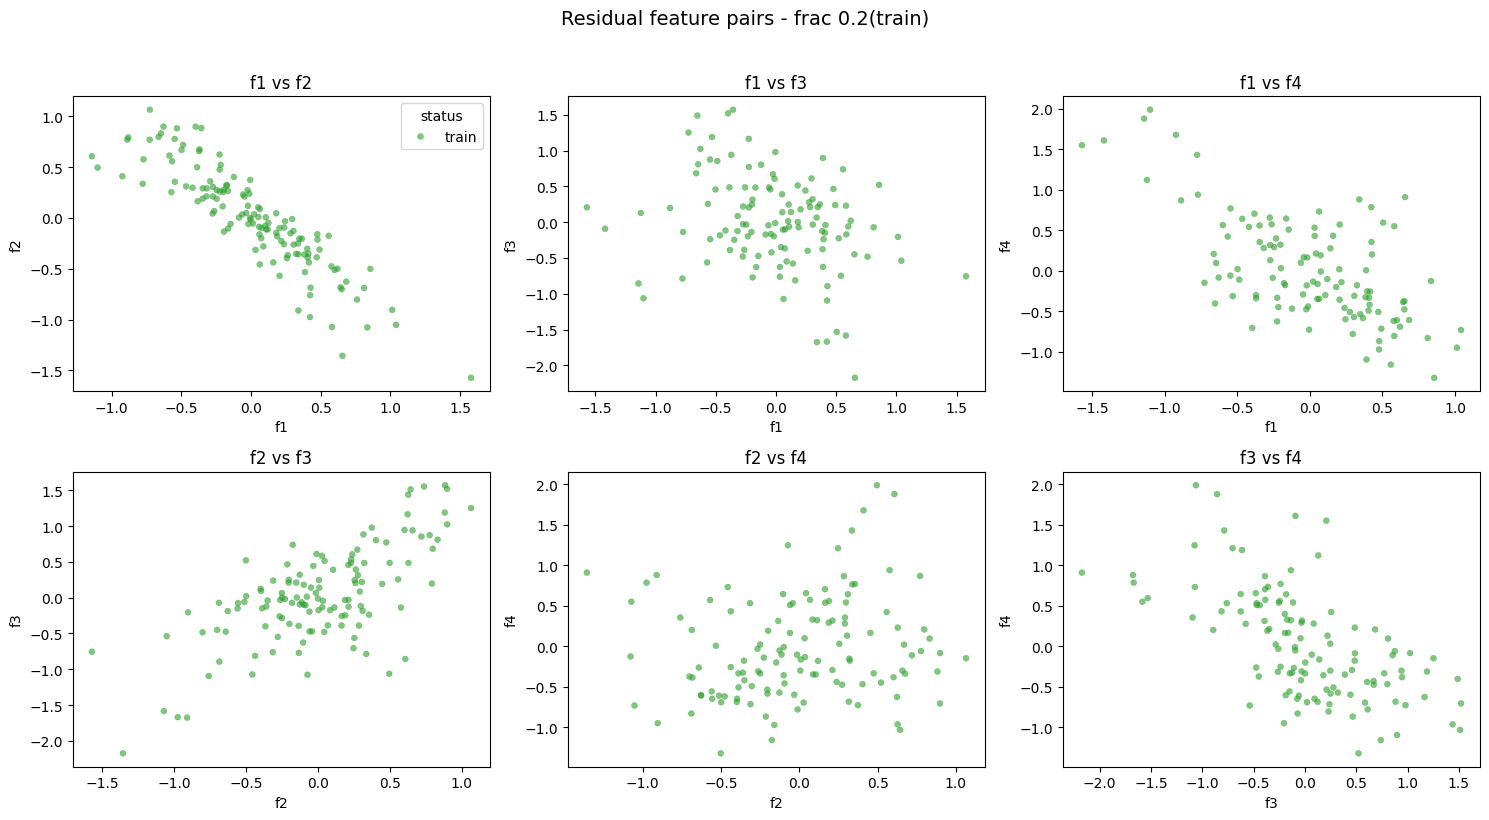

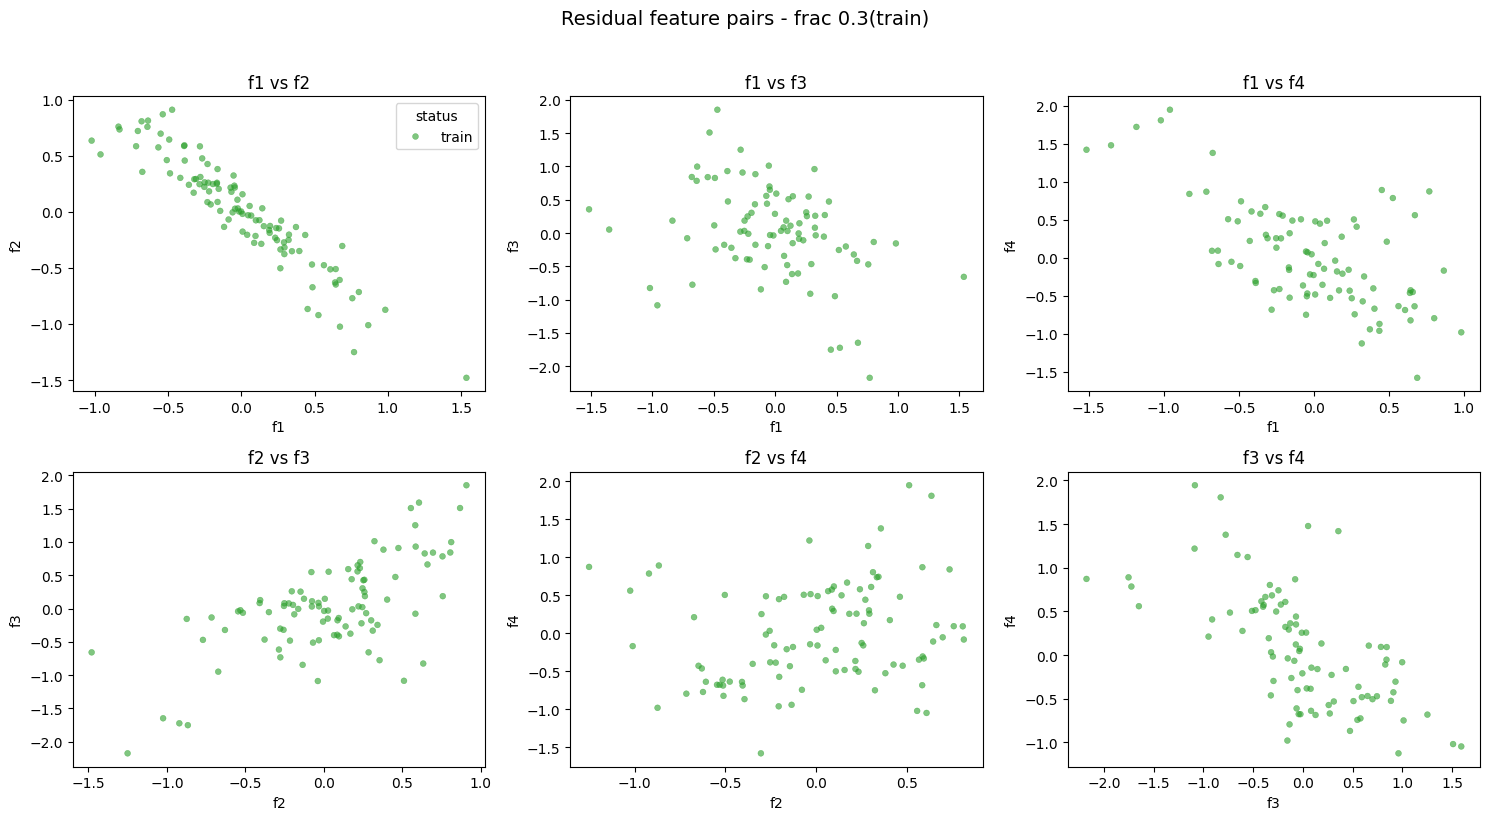

In [3]:
plot_feature_pairs(residual1, 'Residual feature pairs - frac 0.1')
plot_feature_pairs(residual2, 'Residual feature pairs - frac 0.2')
plot_feature_pairs(residual3, 'Residual feature pairs - frac 0.3')

plot_feature_pairs(residual1.iloc[:200,:], 'Residual feature pairs - frac 0.1(train)')
plot_feature_pairs(residual2.iloc[:200,:], 'Residual feature pairs - frac 0.2(train)')
plot_feature_pairs(residual3.iloc[:200,:], 'Residual feature pairs - frac 0.3(train)')


🚀 Processing Missing Rate: 0.1
📌 Missing values in full data:
f1    34
f2    41
f3    41
f4    44
dtype: int64

📌 Missing values in train data:
f1    20
f2    21
f3    27
f4    25
dtype: int64
✅ Trained pair models: 6 / 6

📊 Detection Results (Status vs Final_Damage):
Final_Damage  False  True 
status                    
Damaged          24     56
Normal          116      4
train           198      2

📊 Valid pairs summary:
count    400.00000
mean       4.85750
std        1.64437
min        1.00000
25%        3.00000
50%        6.00000
75%        6.00000
max        6.00000
Name: Valid_Pairs, dtype: float64

📊 Avg_EE_Score summary:
count    400.000000
mean       7.430754
std       19.127918
min     -155.266112
25%        7.674116
50%       13.904119
75%       15.815911
max       17.225767
Name: Avg_EE_Score, dtype: float64

📌 Damage detection summary:
- Damaged start index   : 320
- First detect index    : 324
- First detect sample   : 324
- Detection delay       : 4 samples

🚀 Process

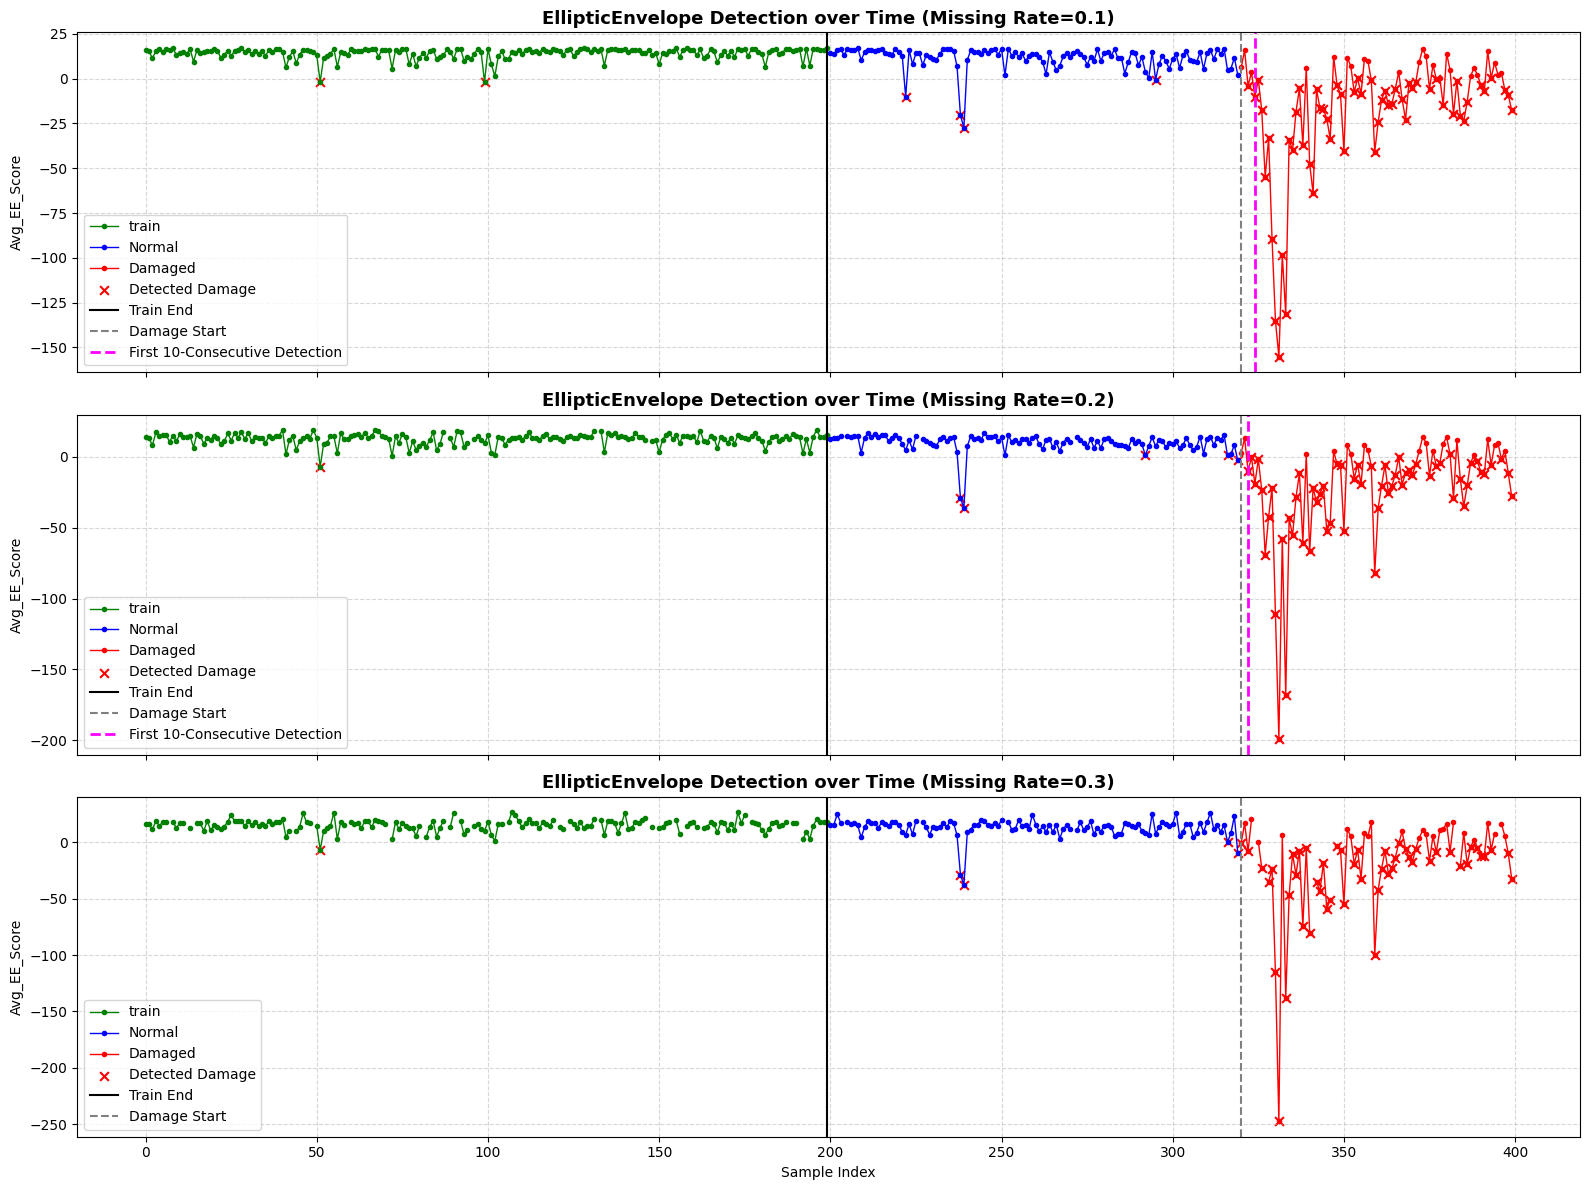

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.covariance import EllipticEnvelope
import pandas as pd

# -----------------------------
# 연속 True 시작점 찾기 함수
# -----------------------------
def find_first_consecutive_detection(bool_series, consecutive_n=10, start_idx=None):
    """
    bool_series: True/False 배열 또는 Series
    consecutive_n: 연속으로 True가 몇 개 나와야 감지로 볼 것인지
    start_idx: 이 인덱스 이후부터만 검사하고 싶을 때 사용 (예: damaged 시작점 320)

    return:
        first_start_index (없으면 None)
    """
    arr = np.asarray(bool_series).astype(bool)

    if start_idx is not None:
        search_arr = arr[start_idx:]
        offset = start_idx
    else:
        search_arr = arr
        offset = 0

    count = 0
    for i, val in enumerate(search_arr):
        if val:
            count += 1
            if count == consecutive_n:
                return offset + i - consecutive_n + 1
        else:
            count = 0

    return None


# 1. 초기 변수 설정
results_ee = {}

# contamination은 비교 대상이므로 필요하면 여러 값 반복 가능
contamination = 0.01

# fraction 개수에 맞게 subplot 생성
n_dataset = len(datasets)
fig, axes = plt.subplots(n_dataset, 1, figsize=(16, 4 * n_dataset), sharex=True)

if n_dataset == 1:
    axes = [axes]

# 2. datasets 딕셔너리 순회
for idx, (frac, df_resid) in enumerate(datasets.items()):
    print(f"\n{'='*60}")
    print(f"🚀 Processing Missing Rate: {frac}")
    print(f"{'='*60}")

    df_resid = df_resid.copy()

    required_cols = feature_cols + ['status']
    missing_cols = [col for col in required_cols if col not in df_resid.columns]
    if missing_cols:
        print(f"❌ 필요한 컬럼이 없습니다: {missing_cols}")
        continue

    for col in feature_cols:
        df_resid[col] = pd.to_numeric(df_resid[col], errors='coerce')

    # sample_idx 기준 정렬
    if 'sample_idx' in df_resid.columns:
        df_resid = df_resid.sort_values('sample_idx').reset_index(drop=True)
    else:
        df_resid = df_resid.reset_index(drop=True)
        df_resid['sample_idx'] = np.arange(len(df_resid))

    train_df = df_resid[df_resid['status'] == 'train'].copy()
    if len(train_df) == 0:
        print("❌ status == 'train' 데이터가 없습니다.")
        continue

    print("📌 Missing values in full data:")
    print(df_resid[feature_cols].isna().sum())

    print("\n📌 Missing values in train data:")
    print(train_df[feature_cols].isna().sum())

    mode_pairs = list(combinations(feature_cols, 2))
    models = {}

    # ---------------------------------------------------------
    # Step A: Pair 조합별 EllipticEnvelope 학습
    # ---------------------------------------------------------
    for pair in mode_pairs:
        pair_name = f"{pair[0]}_{pair[1]}"

        train_pair_df = train_df.dropna(subset=list(pair)).copy()
        train_data_pair = train_pair_df[list(pair)].values

        if len(train_data_pair) < 3:
            print(f"⚠️ pair {pair_name}: 유효 train 데이터 부족으로 skip")
            continue

        try:
            ee_pair = EllipticEnvelope(
                contamination=contamination,
                support_fraction=None,
                random_state=42
            )
            ee_pair.fit(train_data_pair)
            models[pair_name] = ee_pair

        except Exception as e:
            print(f"❌ EllipticEnvelope failed for {pair_name}: {e}")

    if len(models) == 0:
        print("❌ 학습된 EllipticEnvelope 모델이 없습니다.")
        continue

    print(f"✅ Trained pair models: {len(models)} / {len(mode_pairs)}")

    # ---------------------------------------------------------
    # Step B: 앙상블 투표 평가
    # ---------------------------------------------------------
    def get_ensemble_vote(sample_row):
        votes = 0
        valid_pairs = 0
        score_list = []

        for pair in mode_pairs:
            pair_name = f"{pair[0]}_{pair[1]}"

            if pair_name not in models:
                continue

            if sample_row[list(pair)].isna().any():
                continue

            model = models[pair_name]
            pair_data = sample_row[list(pair)].values.reshape(1, -1)

            try:
                pred = model.predict(pair_data)[0]     # 1=inlier, -1=outlier
                score = model.decision_function(pair_data)[0]
                valid_pairs += 1
                score_list.append(score)

                if pred == -1:
                    votes += 1
            except Exception:
                continue

        avg_score = np.mean(score_list) if len(score_list) > 0 else np.nan
        min_score = np.min(score_list) if len(score_list) > 0 else np.nan

        return pd.Series([votes, valid_pairs, avg_score, min_score])

    df_resid[['Vote_Count', 'Valid_Pairs', 'Avg_EE_Score', 'Min_EE_Score']] = df_resid.apply(get_ensemble_vote, axis=1)

    # ---------------------------------------------------------
    # Step C: 최종 판정
    # 과반 투표면 손상
    # ---------------------------------------------------------
    df_resid['Final_Damage'] = df_resid.apply(
        lambda row: False if row['Valid_Pairs'] == 0 else row['Vote_Count'] >= np.ceil(row['Valid_Pairs'] / 2),
        axis=1
    )

    # ---------------------------------------------------------
    # Step D: 연속 10개 손상 판정 시작점 찾기
    # damaged 시작 이후부터만 검사
    # ---------------------------------------------------------
    # status 기준으로 damaged 시작점 찾기
    damaged_indices = df_resid.index[df_resid['status'] == 'Damaged'].tolist()
    damage_start_idx = damaged_indices[0] if len(damaged_indices) > 0 else None

    first_detect_idx = None
    first_detect_sample = None

    if damage_start_idx is not None:
        first_detect_idx = find_first_consecutive_detection(
            df_resid['Final_Damage'],
            consecutive_n=10,
            start_idx=damage_start_idx
        )

        if first_detect_idx is not None:
            first_detect_sample = df_resid.loc[first_detect_idx, 'sample_idx']

    # detection delay 계산
    if damage_start_idx is not None and first_detect_idx is not None:
        detection_delay = first_detect_idx - damage_start_idx
    else:
        detection_delay = None

    # 결과 저장
    results_ee[f'frac_{frac}'] = df_resid.copy()

    # ---------------------------------------------------------
    # 결과 출력
    # ---------------------------------------------------------
    print("\n📊 Detection Results (Status vs Final_Damage):")
    summary = pd.crosstab(df_resid['status'], df_resid['Final_Damage'])
    print(summary)

    print("\n📊 Valid pairs summary:")
    print(df_resid['Valid_Pairs'].describe())

    print("\n📊 Avg_EE_Score summary:")
    print(df_resid['Avg_EE_Score'].describe())

    print("\n📌 Damage detection summary:")
    print(f"- Damaged start index   : {damage_start_idx}")
    print(f"- First detect index    : {first_detect_idx}")
    print(f"- First detect sample   : {first_detect_sample}")
    print(f"- Detection delay       : {detection_delay} samples")

    # ---------------------------------------------------------
    # Step E: 시간 순서 시각화
    # y축은 Avg_EE_Score 사용
    # 손상 판정 True는 빨간 x로 표시
    # ---------------------------------------------------------
    ax = axes[idx]

    x = df_resid['sample_idx'].values
    y = df_resid['Avg_EE_Score'].values

    # 상태별 색상
    color_map = {
        'train': 'green',
        'Normal': 'blue',
        'Damaged': 'red'
    }

    for status_name in ['train', 'Normal', 'Damaged']:
        sub = df_resid[df_resid['status'] == status_name]
        if len(sub) > 0:
            ax.plot(
                sub['sample_idx'],
                sub['Avg_EE_Score'],
                'o-',
                markersize=3,
                linewidth=1,
                color=color_map[status_name],
                label=status_name
            )

    # 손상 판정된 점 표시
    detected = df_resid[df_resid['Final_Damage'] == True]
    if len(detected) > 0:
        ax.scatter(
            detected['sample_idx'],
            detected['Avg_EE_Score'],
            color='red',
            marker='x',
            s=40,
            label='Detected Damage'
        )

    # 경계선 표시
    train_end = df_resid[df_resid['status'] == 'train']['sample_idx'].max()
    if pd.notna(train_end):
        ax.axvline(train_end, color='black', linestyle='-', linewidth=1.5, label='Train End')

    if damage_start_idx is not None:
        damage_start_sample = df_resid.loc[damage_start_idx, 'sample_idx']
        ax.axvline(damage_start_sample, color='gray', linestyle='--', linewidth=1.5, label='Damage Start')

    if first_detect_sample is not None:
        ax.axvline(first_detect_sample, color='magenta', linestyle='--', linewidth=2, label='First 10-Consecutive Detection')

    ax.set_title(f'EllipticEnvelope Detection over Time (Missing Rate={frac})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Avg_EE_Score')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='best')

axes[-1].set_xlabel('Sample Index')
plt.tight_layout()
plt.show()


In [9]:
# 예: frac=0.1 결과 확인
df_resid = results_ee['frac_0.3'].copy()

print("\n📊 Detection Results (Status vs Final_Damage):")
summary = pd.crosstab(df_resid['status'], df_resid['Final_Damage'])
print(summary)

# ---------------------------------------------------------
# Step E: 성능 지표 계산
# 정상 = train + Normal
# 손상 = Damaged
# ---------------------------------------------------------
y_true = (df_resid['status'] == 'Damaged').astype(int)
y_pred = df_resid['Final_Damage'].astype(int)

TP = ((y_true == 1) & (y_pred == 1)).sum()
TN = ((y_true == 0) & (y_pred == 0)).sum()
FP = ((y_true == 0) & (y_pred == 1)).sum()
FN = ((y_true == 1) & (y_pred == 0)).sum()

detection_rate = TP / (TP + FN) if (TP + FN) > 0 else np.nan
false_alarm_rate = FP / (FP + TN) if (FP + TN) > 0 else np.nan
precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else np.nan

print("\n📈 Performance Metrics:")
print(f"TP (correct damage detection)   : {TP}")
print(f"FN (missed damage)              : {FN}")
print(f"FP (false alarm on normal)      : {FP}")
print(f"TN (correct normal detection)   : {TN}")
print(f"Detection Rate (TPR, Recall)    : {detection_rate:.4f}")
print(f"False Alarm Rate (FPR)          : {false_alarm_rate:.4f}")
print(f"Precision                       : {precision:.4f}")
print(f"Accuracy                        : {accuracy:.4f}")

print("\n📊 Valid pairs summary:")
print(df_resid['Valid_Pairs'].describe())



📊 Detection Results (Status vs Final_Damage):
Final_Damage  False  True 
status                    
Damaged          30     50
Normal          116      4
train           199      1

📈 Performance Metrics:
TP (correct damage detection)   : 50
FN (missed damage)              : 30
FP (false alarm on normal)      : 5
TN (correct normal detection)   : 315
Detection Rate (TPR, Recall)    : 0.6250
False Alarm Rate (FPR)          : 0.0156
Precision                       : 0.9091
Accuracy                        : 0.9125

📊 Valid pairs summary:
count    400.000000
mean       2.927500
std        1.980416
min        0.000000
25%        1.000000
50%        3.000000
75%        3.000000
max        6.000000
Name: Valid_Pairs, dtype: float64


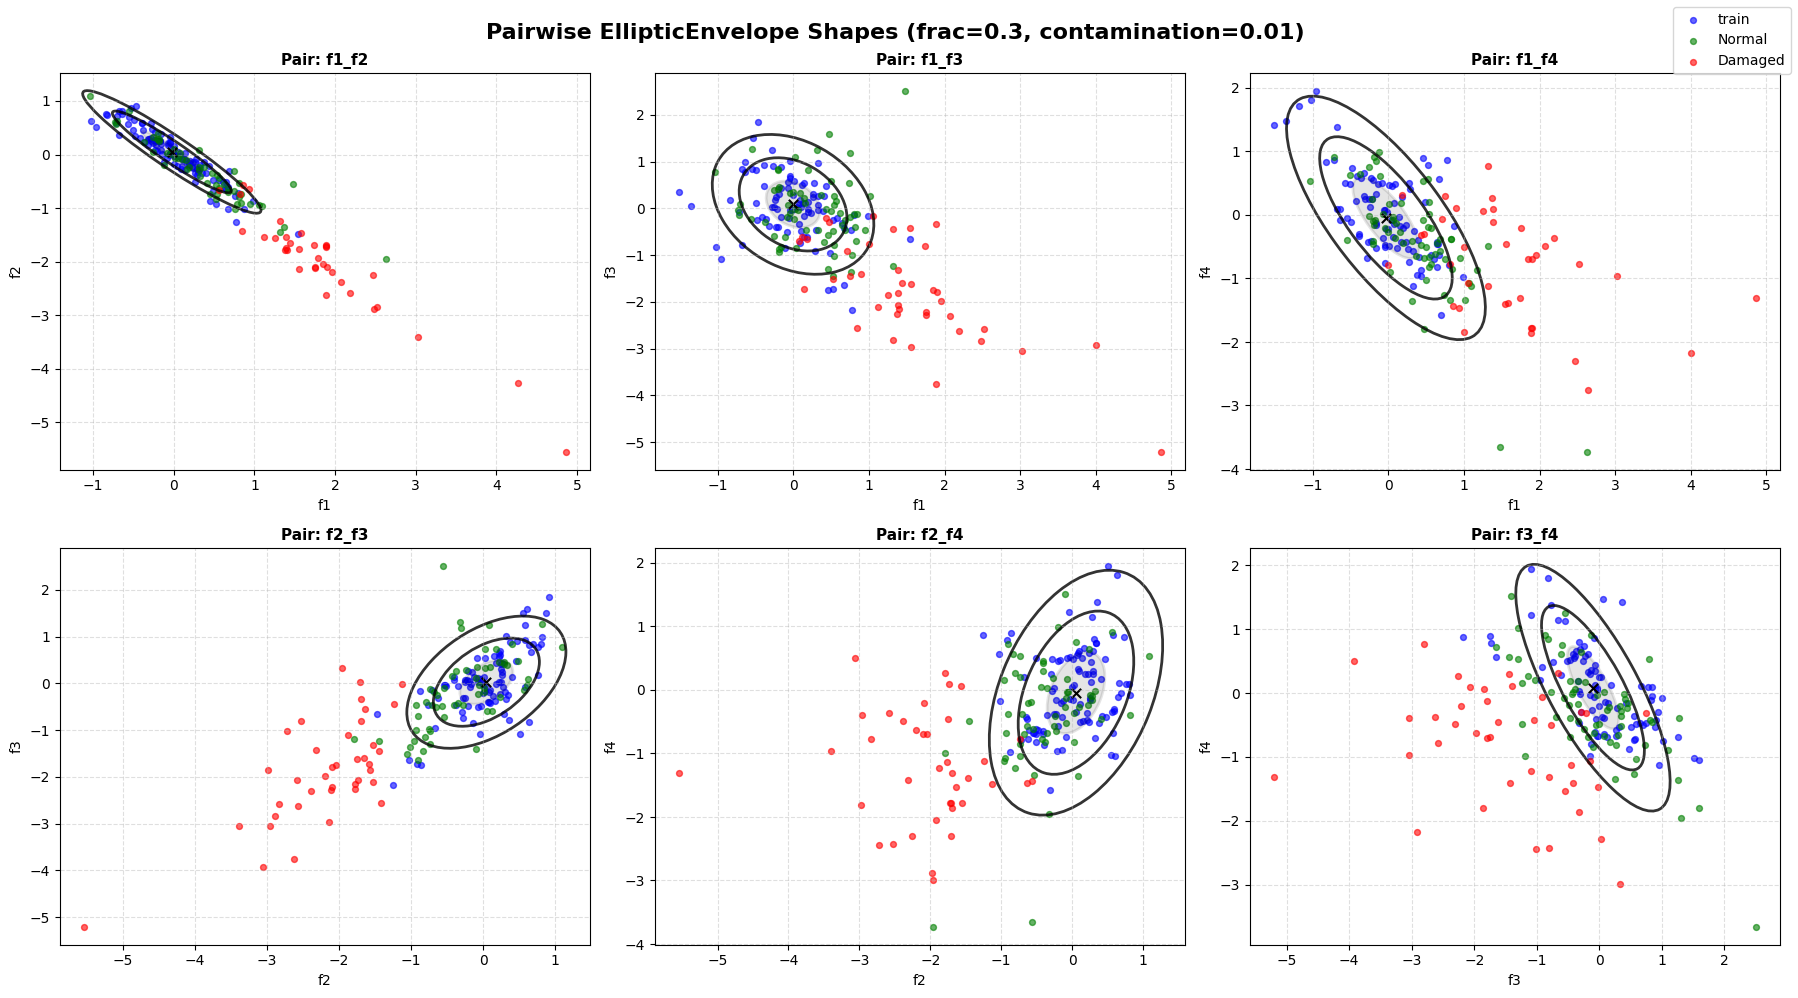

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.patches import Ellipse
from sklearn.covariance import EllipticEnvelope

# =========================
# 사용자 설정
# =========================
target_frac = list(datasets.keys())[2]   # 예: 0.1, 0.2, 0.3
contamination = 0.01
random_state = 42

# =========================
# 내부 함수: robust ellipse
# =========================
def draw_ellipse_from_cov(mean, cov, ax, color='black', alpha=0.15, lw=2):
    if cov.shape != (2, 2):
        return

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    for n_std in [1, 2, 3]:
        width, height = 2 * n_std * np.sqrt(np.maximum(eigvals, 1e-12))
        ellipse = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=angle,
            edgecolor=color,
            facecolor=color if n_std == 1 else 'none',
            lw=lw,
            alpha=alpha if n_std == 1 else 0.8
        )
        ax.add_patch(ellipse)

# =========================
# 대상 데이터 선택
# =========================
if target_frac not in datasets:
    print(f"❌ target_frac={target_frac} 가 datasets에 없습니다.")
    print("사용 가능한 key:", list(datasets.keys()))
else:
    df_plot = datasets[target_frac].copy()

    required_cols = feature_cols + ['status']
    missing_cols = [col for col in required_cols if col not in df_plot.columns]
    if missing_cols:
        print(f"❌ 필요한 컬럼이 없습니다: {missing_cols}")
    else:
        for col in feature_cols:
            df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

        train_df = df_plot[df_plot['status'] == 'train'].copy()

        if len(train_df) == 0:
            print("❌ status == 'train' 데이터가 없습니다.")
        else:
            mode_pairs = list(combinations(feature_cols, 2))
            n_pairs = len(mode_pairs)
            n_cols = 3
            n_rows = int(np.ceil(n_pairs / n_cols))

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
            axes = np.array(axes).reshape(-1)

            status_colors = {
                'train': 'blue',
                'Normal': 'green',
                'Damaged': 'red'
            }

            for ax, pair in zip(axes, mode_pairs):
                pair_name = f"{pair[0]}_{pair[1]}"

                plot_df = df_plot.dropna(subset=list(pair)).copy()
                train_pair_df = train_df.dropna(subset=list(pair)).copy()
                train_data_pair = train_pair_df[list(pair)].values

                for status, color in status_colors.items():
                    sub = plot_df[plot_df['status'] == status]
                    if len(sub) > 0:
                        ax.scatter(
                            sub[pair[0]], sub[pair[1]],
                            s=18, alpha=0.6, c=color, label=status
                        )

                if len(train_data_pair) >= 3:
                    try:
                        ee_pair = EllipticEnvelope(
                            contamination=contamination,
                            support_fraction=None,
                            random_state=random_state
                        )
                        ee_pair.fit(train_data_pair)

                        mean = ee_pair.location_
                        cov = ee_pair.covariance_

                        draw_ellipse_from_cov(mean, cov, ax, color='black', alpha=0.10, lw=2)
                        ax.scatter(mean[0], mean[1], c='black', s=45, marker='x')

                    except Exception:
                        ax.text(
                            0.5, 0.5,
                            f'EE failed\n{pair_name}',
                            transform=ax.transAxes,
                            ha='center', va='center',
                            fontsize=10, color='black'
                        )

                ax.set_title(f'Pair: {pair_name}', fontsize=11, fontweight='bold')
                ax.set_xlabel(pair[0])
                ax.set_ylabel(pair[1])
                ax.grid(True, linestyle='--', alpha=0.4)

            for j in range(len(mode_pairs), len(axes)):
                fig.delaxes(axes[j])

            handles, labels = axes[0].get_legend_handles_labels()
            fig.legend(handles, labels, loc='upper right')
            fig.suptitle(
                f'Pairwise EllipticEnvelope Shapes (frac={target_frac}, contamination={contamination})',
                fontsize=16,
                fontweight='bold'
            )
            plt.tight_layout()
            plt.show()

해당 코드의 장점은 결측이 존재하더라도 다른 페어에서 거리를 계산해서 voting하는 시스템이기 때문에 모두 결측이 있더라도 전체 판단 가능